In [1]:
import math 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
def f(x):
    return 3*x**2 - 4*x +5

f(3.0)

20.0

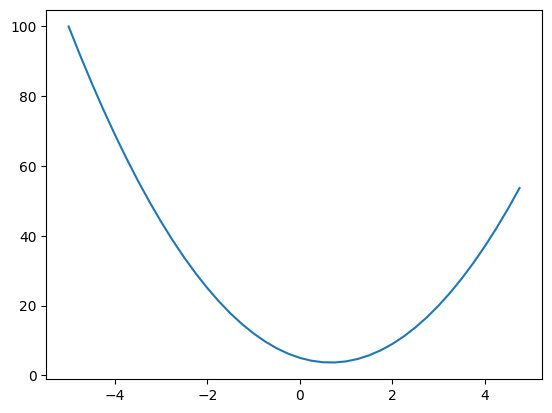

In [5]:
xs = np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [9]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # ---- arithmetic ----
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):  # handles number + Value
        return self + other
    
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)
    
    def __rsub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * (self.data ** (other-1))) * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)

    def __neg__(self):  # unary negation
        return self * -1

    # ---- activations ----
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out    

    # ---- backprop ----
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

In [12]:
a = Value(2.0)
b= Value(4.0)

a * b
 

Value(data=8.0)

In [15]:
from graphviz import Digraph

def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        dot.node(name=uid , label ="{%s | data %.4f |grad %.4f}"%(n.label , n.data , n.grad),shape='record')
        if n._op:
            dot.node(name = uid + n._op , label = n._op) 
            dot.edge(uid+n._op,uid)

    for n1 , n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) +n2._op)         

    return dot              


    
        

In [18]:
#In BackProp in Neuron Manually

x1=Value(2.0 , label='x1')
x2=Value(0.0 , label='x2')

w1=Value(-3.0,label='w1')
w2=Value(1.0 , label='w2')

b=Value(6.8813735870195432 , label='b')

x1w1 = x1*w1 ; x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1w1+x2w2'

n= x1w1x2w2+b; n.label='n'


e = (2*n).exp() 
o =(e-1)/(e+1)
e.label = 'e'
o.label ='o'


o.backward()






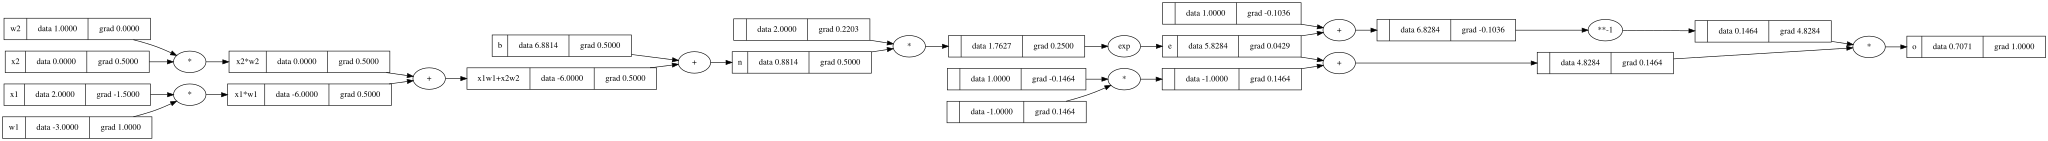

In [19]:
draw_dot(o)

In [141]:
# neural networks
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform (-1,1))

    def __call__ (self , x):
        act = sum((wi*xi for wi , xi in zip(self.w , x)),self.b)
        out = act.tanh()
        return out 
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__ (self , nin , nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__ (self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for  neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__ (self , nin , nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] 


    def __call__ (self , x):
        for layer in self.layers:
            x = layer(x)
        return x   

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()] 




x = [2.0,3.0,-1.0]
n= MLP(3 , [4,4,1])
n(x)      



        
 

Value(data=0.4641634127866279)

In [140]:
n.parameters()

[Value(data=-20.626681037691917),
 Value(data=4.1673690144114),
 Value(data=-30.343678971277523),
 Value(data=-13.526476261785533),
 Value(data=-40.854889359816994),
 Value(data=-10.256983269884792),
 Value(data=-27.232111188304117),
 Value(data=-30.166437521917285),
 Value(data=78.1719271195648),
 Value(data=-9.9945237796637),
 Value(data=41.42419636290724),
 Value(data=39.733955032042715),
 Value(data=-15.38721076006164),
 Value(data=0.1298567313380824),
 Value(data=-11.607635898423712),
 Value(data=-9.319214031691734),
 Value(data=-1.1575307043291203),
 Value(data=-4.235761021087027),
 Value(data=-19.003747202092434),
 Value(data=0.7269641459236911),
 Value(data=-7.337200632170598),
 Value(data=-17.07960322462197),
 Value(data=-1.486934152347377),
 Value(data=-12.510458894207584),
 Value(data=-10.832516661760236),
 Value(data=-20.719324340609017),
 Value(data=-2.7691294622717892),
 Value(data=-1.1735070537315488),
 Value(data=10.025153791101513),
 Value(data=-3.699636843230986),
 Va

In [137]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0 , 1.0 ,-1.0],
]

ys = [1.0 , -1.0 , -1.0 , 1.0]


In [144]:
for k in range(25):
     ypred = [n(x) for x in xs]
     loss = sum((yout-ygt)**2 for ygt , yout in zip(ys,ypred))

     for p in n.parameters():
          p.grad=0.0
     loss.backward()     
     
     loss.backward()

     for p in n.parameters():
          p.data += -0.05 * p.grad

     print(k, loss.data)     

0 7.9990921667352115
1 7.999084484787835
2 7.999076671773942
3 7.999068724311249
4 7.999060638900132
5 7.999052411918491
6 7.999044039616346
7 7.999035518110156
8 7.999026843376806
9 7.999018011247299
10 7.999009017400072
11 7.9989998573539625
12 7.998990526460779
13 7.9989810198974425
14 7.998971332657688
15 7.998961459543297
16 7.998951395154796
17 7.998941133881642
18 7.998930669891809
19 7.998919997120751
20 7.998909109259704
21 7.998897999743277
22 7.998886661736278
23 7.998875088119714
24 7.998863271475914


In [145]:
ypred

[Value(data=0.9998729355429464),
 Value(data=0.9998442428855573),
 Value(data=0.9998715564632075),
 Value(data=0.9998689371988122)]

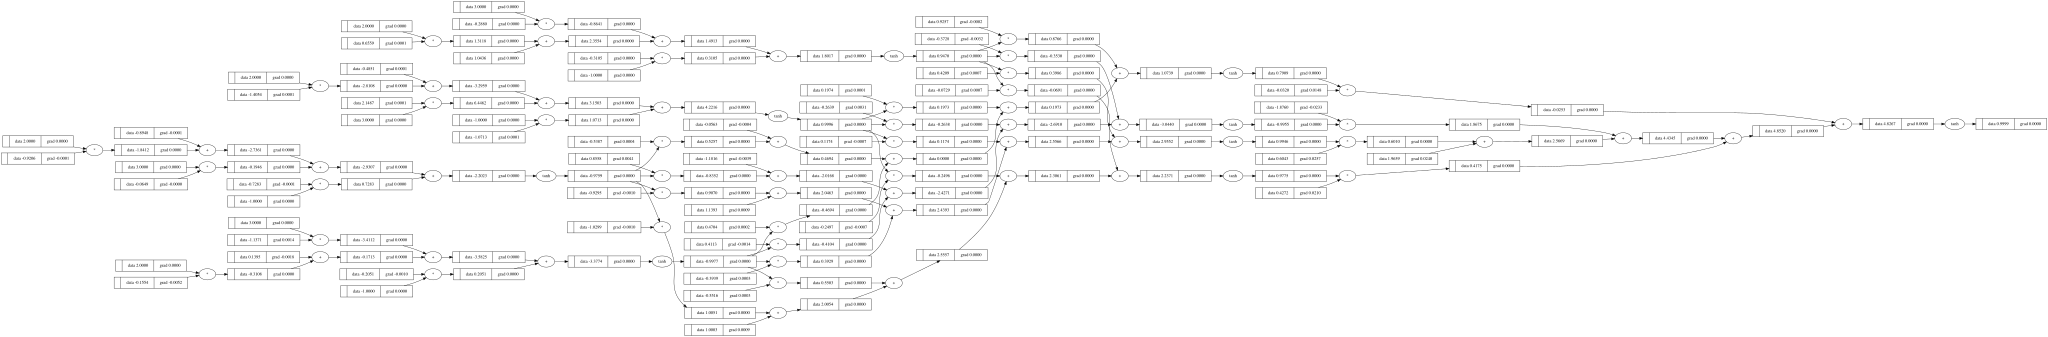

In [146]:
draw_dot(n(x))